In [1]:
from sklearn import datasets

In [2]:
iris=datasets.load_iris()

In [3]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
import pandas as pd
X=iris.data
y=iris.target

In [5]:
X=pd.DataFrame(X)

In [6]:
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
X.shape

(150, 4)

# EDA


In [8]:
import seaborn as sns

<Axes: xlabel='0', ylabel='Count'>

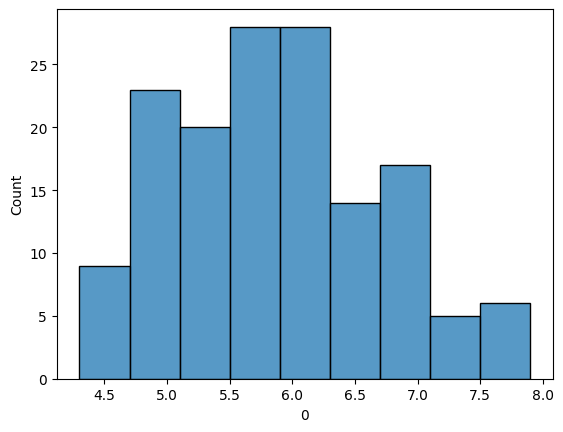

In [9]:
sns.histplot(X[0])

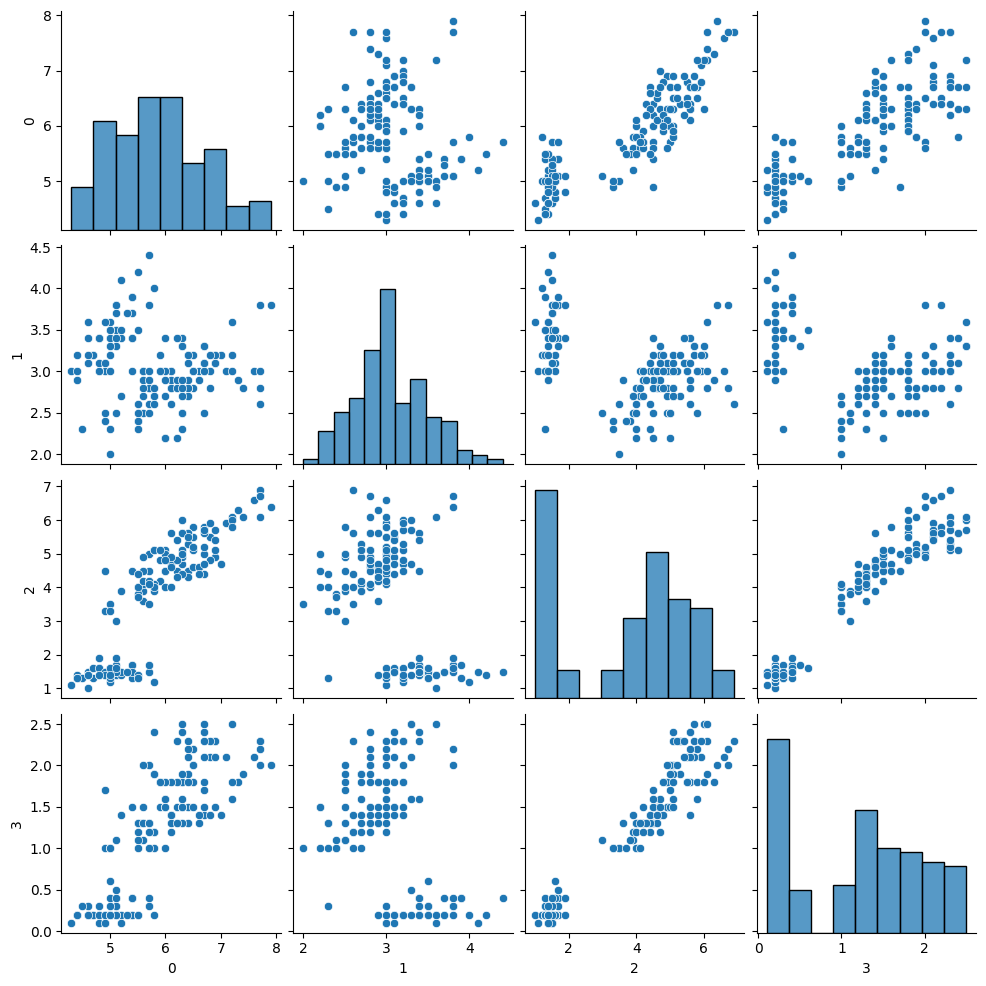

In [10]:
sns.pairplot(X)
# Data is linear

<Axes: >

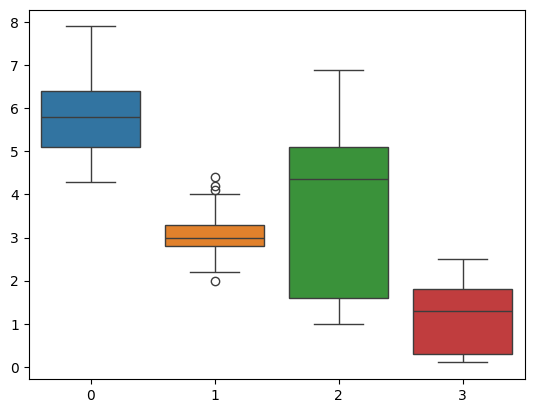

In [11]:
sns.boxplot(X)

3 columns does not have out,Where as few columns have outliers only


# PREPROCESSING

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.3,random_state=123,stratify=y)

In [13]:
y_test

array([2, 0, 0, 0, 1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 1, 2, 1, 2, 2, 1, 1, 2,
       2, 1, 2, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 1, 0, 2, 0, 0, 1, 2, 0, 0,
       2, 0, 0, 1, 0, 1, 2, 1, 0, 2, 2, 2, 2, 0, 1, 2, 1, 1, 1, 2, 0, 1,
       2, 0, 1, 1, 0, 1, 1, 2, 0, 2, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 2, 1,
       0, 0, 2, 0, 2, 2, 2, 0, 1, 0, 1, 1, 1, 0, 2, 2, 2])

# MODEL

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
logi=LogisticRegression()

In [16]:
logi.fit(X_train,y_train)

LogisticRegression()

In [17]:
y_pred=logi.predict(X_test)

In [18]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [19]:
print(confusion_matrix(y_test,y_pred))

[[35  0  0]
 [ 0 33  2]
 [ 0  5 30]]


In [20]:
accuracy_score(y_test,y_pred)*100

93.33333333333333

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.87      0.94      0.90        35
           2       0.94      0.86      0.90        35

    accuracy                           0.93       105
   macro avg       0.94      0.93      0.93       105
weighted avg       0.94      0.93      0.93       105



In [24]:
# dont work on jupyter
!pip install gradio


In [25]:
from gradio.components import label
import gradio as gr

def predict_species(sepal_length, sepal_width, petal_length, petal_width):
  features = [[sepal_length, sepal_width, petal_length, petal_width]]
  prediction = logi.predict(features)
  predicted_class = logi.classes_[prediction][0]
  fp={logi.classes_[0]:'Setosa',logi.classes_[1]:'Versicolor',logi.classes_[2]:'Virginica'}
  return fp[predicted_class]

with gr.Blocks() as demo:
    # input fields for the features
    sepal_length = gr.Slider(minimum=4, maximum=8, step=0.1, label="Sepal Length (cm)")
    sepal_width = gr.Slider(minimum=2, maximum=5, step=0.1, label="Sepal Width (cm)")
    petal_length = gr.Slider(minimum=1, maximum=7, step=0.1, label="Petal Length (cm)")
    petal_width = gr.Slider(minimum=0, maximum=3, step=0.1, label="Petal Width (cm)")

    # BUTTON TO PREDICT AND OUTPUT TEXT FIELD FOR RESULT
    submit_btn = gr.Button("Predict species")
    output = gr.Textbox(label="Predicted Species")

    # WHEN THE BUTTON IS CLICKED, CALL THE PREDICTION FUNCTION
    submit_btn.click(fn=predict_species, inputs=[sepal_length, sepal_width, petal_length, petal_width], outputs=output)

# LAUNCH THE GARDIO APP
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://061a8c3cabcb4f5987.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
